In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, LabelEncoder 
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder


In [2]:
df=pd.read_csv("C:\\Users\\User\\Desktop\\python\\deeplearing\\Loan_default.csv")
df

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [3]:
categorical_binary = ['HasMortgage', 'HasDependents', 'HasCoSigner', 'Default']
categorical_multi = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose'] 

In [4]:
label_enc = LabelEncoder() 
for col in categorical_binary:
 df[col] = label_enc.fit_transform(df[col])

In [5]:
df = pd.get_dummies(df, 
                    columns=[col for col in categorical_multi if col in df.columns], 
                    drop_first=True)


In [6]:
x= df.drop(['LoanID','Default'],axis=1)
y=df["Default"]

In [7]:
x_train ,x_test ,y_train , y_test = train_test_split(x,y,test_size=0.2, random_state= 42)

In [8]:
scaler =StandardScaler()
x_train =scaler.fit_transform(x_train)
x_test =scaler.transform(x_test)

In [9]:
import tensorflow as tf 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense 
from tensorflow.keras.optimizers import Adam, SGD

In [10]:
model =Sequential([Dense(32,activation= 'relu', input_dim= x_test.shape[1]), 
                   Dense(16, activation= 'relu'),
                   Dense(1, activation= 'sigmoid')])

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(loss = 'binary_crossentropy',optimizer=Adam(0.001), metrics=['accuracy'])

In [ ]:
histroy= model.fit(x_train,y_train ,epochs=50 ,batch_size=32, validation_split=0.2)

Epoch 1/50
5107/5107 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8836 - loss: 0.3246 - val_accuracy: 0.8871 - val_loss: 0.3126
Epoch 2/50
5107/5107 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8846 - loss: 0.3169 - val_accuracy: 0.8876 - val_loss: 0.3118
Epoch 3/50
5107/5107 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8848 - loss: 0.3157 - val_accuracy: 0.8881 - val_loss: 0.3114
Epoch 4/50
5107/5107 ━━━━━━━━━━━━━━━━━━━━ 5s 986us/step - accuracy: 0.8851 - loss: 0.3150 - val_accuracy: 0.8885 - val_loss: 0.3110
Epoch 5/50
5107/5107 ━━━━━━━━━━━━━━━━━━━━ 5s 970us/step - accuracy: 0.8850 - loss: 0.3144 - val_accuracy: 0.8878 - val_loss: 0.3113
Epoch 6/50
5107/5107 ━━━━━━━━━━━━━━━━━━━━ 5s 972us/step - accuracy: 0.8851 - loss: 0.3140 - val_accuracy: 0.8878 - val_loss: 0.3105
Epoch 7/50
5107/5107 ━━━━━━━━━━━━━━━━━━━━ 5s 973us/step - accuracy: 0.8856 - loss: 0.3136 - val_accuracy: 0.8878 - val_loss: 0.3108
Epoch 8/50
5107/5107 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8855 - loss: 0

In [ ]:
model.compile(loss="mse", optimizer=SGD(learning_rate=0.01), metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
5107/5107 ━━━━━━━━━━━━━━━━━━━━ 5s 847us/step - accuracy: 0.8873 - loss: 0.0896 - val_accuracy: 0.8868 - val_loss: 0.0915
Epoch 2/50
5107/5107 ━━━━━━━━━━━━━━━━━━━━ 4s 868us/step - accuracy: 0.8874 - loss: 0.0895 - val_accuracy: 0.8870 - val_loss: 0.0914
Epoch 3/50
5107/5107 ━━━━━━━━━━━━━━━━━━━━ 4s 841us/step - accuracy: 0.8875 - loss: 0.0894 - val_accuracy: 0.8869 - val_loss: 0.0914
Epoch 4/50
5107/5107 ━━━━━━━━━━━━━━━━━━━━ 5s 903us/step - accuracy: 0.8876 - loss: 0.0894 - val_accuracy: 0.8866 - val_loss: 0.0916
Epoch 5/50
5107/5107 ━━━━━━━━━━━━━━━━━━━━ 4s 831us/step - accuracy: 0.8876 - loss: 0.0893 - val_accuracy: 0.8868 - val_loss: 0.0915
Epoch 6/50
5107/5107 ━━━━━━━━━━━━━━━━━━━━ 4s 817us/step - accuracy: 0.8876 - loss: 0.0893 - val_accuracy: 0.8866 - val_loss: 0.0916
Epoch 7/50
5107/5107 ━━━━━━━━━━━━━━━━━━━━ 4s 869us/step - accuracy: 0.8877 - loss: 0.0893 - val_accuracy: 0.8865 - val_loss: 0.0916
Epoch 8/50
5107/5107 ━━━━━━━━━━━━━━━━━━━━ 5s 881us/step - accuracy: 0.8878 -

In [ ]:
loss ,accurary =model.evaluate(x_test,y_test)
print("Test Accuracy:",accurary)

1596/1596 ━━━━━━━━━━━━━━━━━━━━ 1s 626us/step - accuracy: 0.8858 - loss: 0.0918
Test Accuracy: 0.8858429789543152


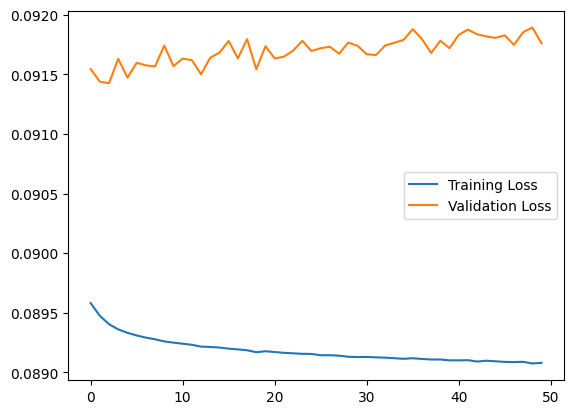

In [ ]:
plt.plot(history.history['loss'], label='Training Loss') 
plt.plot(history.history['val_loss'], label='Validation Loss') 
plt.legend() 
plt.show()